## Load and Inspect the Data

In [3]:
import pandas as pd
import sklearn

df = pd.read_csv('dataset.csv')

# df.head()
df.info()
# df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10678 entries, 0 to 10677
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   task_size        10678 non-null  float64
 1   cpu_demand       10678 non-null  float64
 2   memory_demand    10678 non-null  float64
 3   network_latency  10678 non-null  float64
 4   io_operations    10678 non-null  float64
 5   disk_usage       10678 non-null  float64
 6   num_connections  10678 non-null  float64
 7   priority_level   10678 non-null  float64
 8   target           10678 non-null  int64  
 9   timestamp        10678 non-null  object 
dtypes: float64(8), int64(1), object(1)
memory usage: 834.3+ KB


## Clean the dataset

### Handle timestamp

In [4]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp")
df.head()

,task_size,cpu_demand,memory_demand,network_latency,io_operations,disk_usage,num_connections,priority_level,target,timestamp
1383,-1.928647,-0.808928,-0.845246,2.537360,-2.777643,-3.009304,0.122484,2.000661,0,2022-02-11 08:17:47
6550,-3.425279,-1.140099,0.241193,-0.510030,0.268814,-2.777008,0.222124,0.488208,0,2022-02-11 09:39:14
9307,-0.951967,2.222200,-2.673036,0.029093,0.084621,-0.783362,-1.276021,1.611084,1,2022-02-11 11:53:07
3437,-1.986164,-1.732544,-1.990368,1.100686,-0.426128,-4.384974,-1.122700,0.753957,1,2022-02-11 15:56:44
5057,-1.238387,0.587157,1.449966,-0.166007,-1.782024,1.822197,0.298395,0.670457,1,2022-02-11 16:16:37


### Check for missing values

In [6]:
df.isnull().sum()

task_size          0
cpu_demand         0
memory_demand      0
network_latency    0
io_operations      0
disk_usage         0
num_connections    0
priority_level     0
target             0
timestamp          0
dtype: int64

### Flip target meaning, for 1 to mean SLA violation and 0 to mean SLA met

In [7]:
df["target"].value_counts()

target
1    5357
0    5321
Name: count, dtype: int64

In [9]:
df["target"] = 1 - df["target"]
df["target"].value_counts()

target
1    5357
0    5321
Name: count, dtype: int64

## Feature Selection

In [10]:
features = [
 "cpu_demand",
 "memory_demand",
 "network_latency",
 "io_operations",
 "num_connections"
]

x = df[features]
y = df["target"]

## Data split into train. validation and split
In Chronological order

In [11]:
train_size = int(len(df) * 0.7)
validation_size = int(len(df) * 0.15)
print(train_size, validation_size)
print(train_size+validation_size)

x_train = x[:train_size]
y_train = y[:train_size]

x_validation = x[train_size:train_size+validation_size]
y_validation = y[train_size:train_size+validation_size]

x_test = x[train_size+validation_size:]
y_test = y[train_size+validation_size:]

7474 1601
9075


## Train with Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Evaluate with validation set

In [13]:
from sklearn.metrics import classification_report, roc_auc_score

validation_predictions = model.predict(x_validation)
validation_probabilities = model.predict_proba(x_validation)[:,1]

print(classification_report(y_validation, validation_predictions))
print("ROC-AUC: ", roc_auc_score(y_validation, validation_probabilities))

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       839
           1       0.80      0.79      0.79       762

    accuracy                           0.80      1601
   macro avg       0.80      0.80      0.80      1601
weighted avg       0.80      0.80      0.80      1601

ROC-AUC:  0.8822151104771021


In [14]:
threshold = 0.4
validation_custom = (validation_probabilities >= threshold).astype(int)

print(classification_report(y_validation, validation_custom))

              precision    recall  f1-score   support

           0       0.84      0.73      0.78       839
           1       0.74      0.85      0.79       762

    accuracy                           0.78      1601
   macro avg       0.79      0.79      0.78      1601
weighted avg       0.79      0.78      0.78      1601



In [15]:
threshold = 0.35
validation_custom = (validation_probabilities >= threshold).astype(int)

print(classification_report(y_validation, validation_custom))

              precision    recall  f1-score   support

           0       0.86      0.68      0.76       839
           1       0.71      0.88      0.78       762

    accuracy                           0.77      1601
   macro avg       0.78      0.78      0.77      1601
weighted avg       0.79      0.77      0.77      1601



## Coefficients

In [16]:
import numpy as np

for feature, coef in zip(features, model.coef_[0]):
 print(feature, coef)

cpu_demand 1.144501654664211
memory_demand 0.04729080433716196
network_latency 0.009005554592450537
io_operations 0.3208009018712131
num_connections 0.009796333744292087


## Precision-Recall Curve

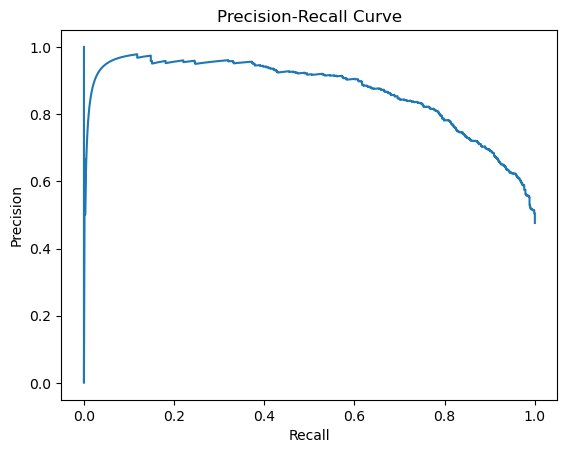

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

val_probs = model.predict_proba(x_validation)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_validation, val_probs)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

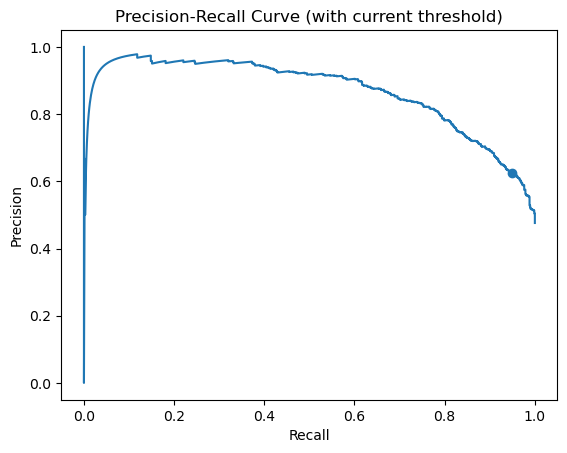

In [19]:
import numpy as np

threshold = 0.2

idx = np.argmin(np.abs(thresholds - threshold))

plt.figure()
plt.plot(recall, precision)
plt.scatter(recall[idx], precision[idx])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (with current threshold)")
plt.show()

In [20]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_validation, val_probs)
print("Average Precision:", ap)

Average Precision: 0.8678542449788231


In [22]:
import numpy as np
target_recall = 0.98

idx = np.argmin(np.abs(recall - target_recall))

best_threshold = thresholds[idx]
best_precision = precision[idx]
best_recall = recall[idx]

print("Threshold:", best_threshold)
print("Precision:", best_precision)
print("Recall:", best_recall)

Threshold: 0.10344792382392563
Precision: 0.5595505617977528
Recall: 0.9803149606299213
